✅ Libraries loaded successfully!
Sum of probabilities: 1.0
✅ Created 100,000 flights
Delayed flights: 29.9%
On-time flights: 70.1%

First 5 rows:
   MONTH  DAY_OF_WEEK  DEP_HOUR  DISTANCE  AIRLINE_CODE  ORIGIN_CODE  \
0      7            2        20       400             5           11   
1      4            2        16       200             7           14   
2     11            5         8       600             0           17   
3      8            1         9      1500             0           30   
4      5            3        11      1000             1           20   

   DEST_CODE  IS_DELAYED  
0         14           0  
1         37           1  
2         36           1  
3         30           0  
4         36           0  

Features shape: (100000, 7)
Target shape: (100000,)
Training set: 80,000 flights
Testing set: 20,000 flights

Training Random Forest model...
✅ Model training complete!

🎯 MODEL ACCURACY: 69.63%

📋 Classification Report:
              precision    recall  f1

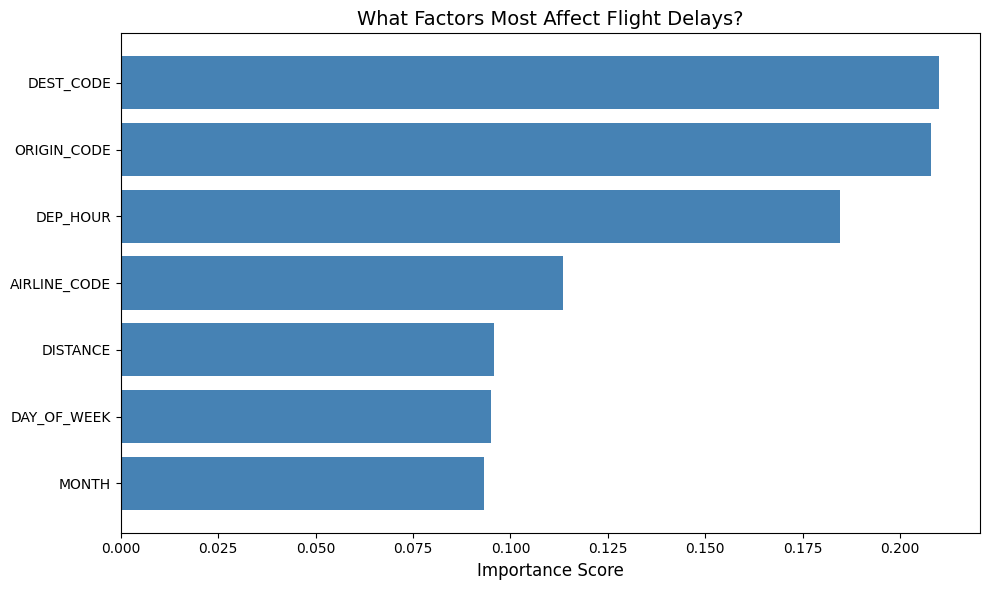

✅ Saved: feature_importance.png


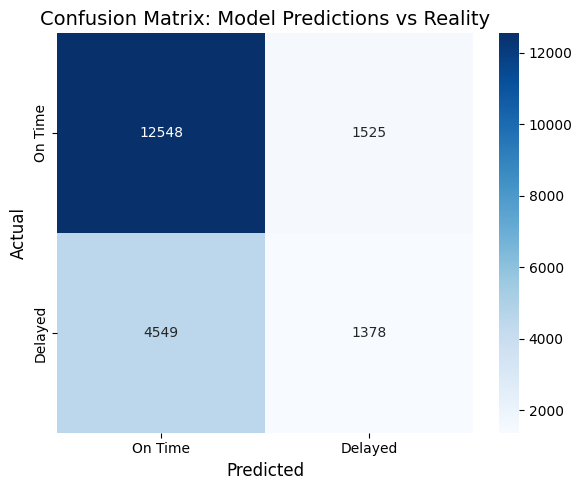

✅ Saved: confusion_matrix.png


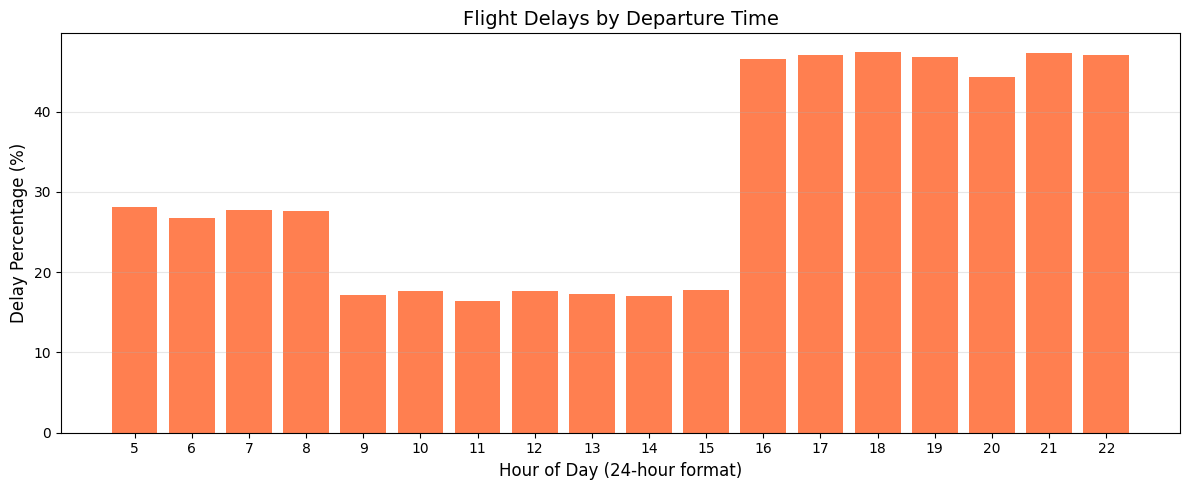

✅ Worst time for delays: 18:00 (47.4% delay rate)
✅ Best time to fly: 11:00 (16.5% delay rate)


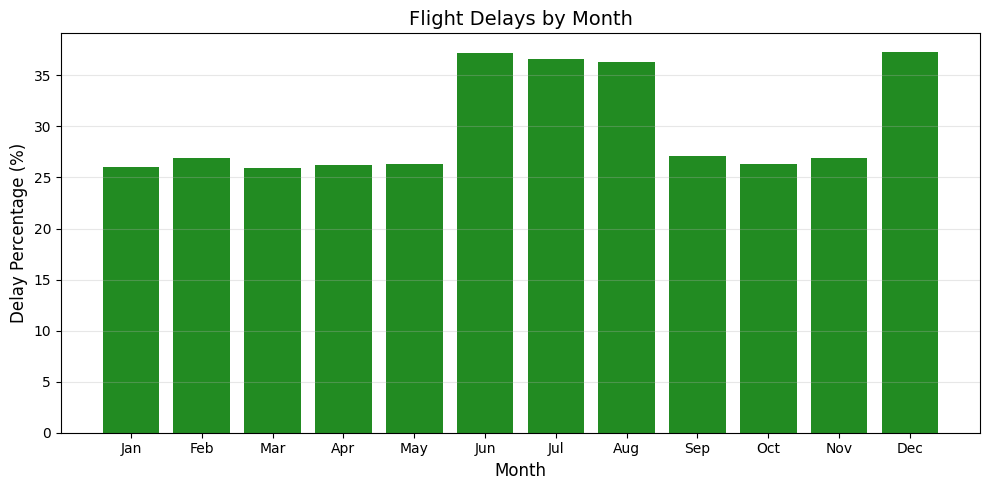

✅ Saved: delays_by_month.png

📊 FINAL SUMMARY
Total flights analyzed: 100,000
Model accuracy: 69.63%
Most important factor: DEST_CODE
Second most important: ORIGIN_CODE
Worst hour for delays: 18:00
Best hour to fly: 11:00

✅ All images saved. Download them to upload to GitHub!

📁 Files to download:
   - feature_importance.png
   - confusion_matrix.png
   - delays_by_hour.png
   - delays_by_month.png (bonus)


In [2]:
# Flight Delay Predictor - CORRECTED CODE
# Run this entire notebook step by step

# ============================================
# STEP 1: Install and import libraries
# ============================================
!pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ Libraries loaded successfully!")

# ============================================
# STEP 2: Create a sample dataset
# ============================================

np.random.seed(42)

n_flights = 100000

# Corrected: probabilities for hours 5-22 (18 hours) that sum to 1
# Hours from 5 AM to 10 PM (more flights during day, fewer late night)
hours = list(range(5, 23))  # [5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22]
# Probabilities that sum to 1 (peak at 8-10 AM and 4-7 PM)
hour_probs = [0.02, 0.04, 0.06, 0.08, 0.08, 0.07, 0.07, 0.06, 0.06, 0.05, 0.05, 0.06, 0.07, 0.07, 0.06, 0.04, 0.03, 0.03]

# Verify sum is 1
print(f"Sum of probabilities: {sum(hour_probs)}")  # Should be 1.0

# Generate data
data = {
    'MONTH': np.random.randint(1, 13, n_flights),
    'DAY_OF_WEEK': np.random.randint(1, 8, n_flights),
    'DEP_HOUR': np.random.choice(hours, n_flights, p=hour_probs),
    'DISTANCE': np.random.choice([200,400,600,800,1000,1500,2000,2500], n_flights,
                                  p=[0.2, 0.2, 0.15, 0.15, 0.1, 0.1, 0.05, 0.05]),
    'AIRLINE_CODE': np.random.randint(0, 10, n_flights),
    'ORIGIN_CODE': np.random.randint(0, 50, n_flights),
    'DEST_CODE': np.random.randint(0, 50, n_flights),
}

df = pd.DataFrame(data)

# Create delay probability based on realistic factors
delay_prob = (
    (df['DEP_HOUR'] >= 16).astype(int) * 0.30 +   # Evening delays
    (df['DEP_HOUR'] <= 8).astype(int) * 0.10 +    # Early morning
    (df['DISTANCE'] > 1500).astype(int) * 0.15 +  # Long flights
    (df['MONTH'].isin([6,7,8,12])).astype(int) * 0.10 +  # Summer/winter
    np.random.random(n_flights) * 0.25            # Random noise
)
delay_prob = np.clip(delay_prob, 0, 1)

# Create target variable (1 = delayed, 0 = on time)
df['IS_DELAYED'] = (np.random.random(n_flights) < delay_prob).astype(int)

print(f"✅ Created {len(df):,} flights")
print(f"Delayed flights: {df['IS_DELAYED'].mean()*100:.1f}%")
print(f"On-time flights: {(1-df['IS_DELAYED'].mean())*100:.1f}%")
print("\nFirst 5 rows:")
print(df.head())

# ============================================
# STEP 3: Prepare features and target
# ============================================

features = ['MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DISTANCE',
            'AIRLINE_CODE', 'ORIGIN_CODE', 'DEST_CODE']

X = df[features]
y = df['IS_DELAYED']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# ============================================
# STEP 4: Split data into train and test sets
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} flights")
print(f"Testing set: {len(X_test):,} flights")

# ============================================
# STEP 5: Train the Random Forest model
# ============================================

print("\nTraining Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("✅ Model training complete!")

# ============================================
# STEP 6: Evaluate the model
# ============================================

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"🎯 MODEL ACCURACY: {accuracy * 100:.2f}%")
print(f"{'='*50}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Delayed']))

# ============================================
# STEP 7: Create Visualisation 1 - Feature Importance
# ============================================

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.title('What Factors Most Affect Flight Delays?', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("✅ Saved: feature_importance.png")

# ============================================
# STEP 8: Create Visualisation 2 - Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix: Model Predictions vs Reality', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("✅ Saved: confusion_matrix.png")

# ============================================
# STEP 9: Create Visualisation 3 - Delays by Hour
# ============================================

hourly_delay = df.groupby('DEP_HOUR')['IS_DELAYED'].mean() * 100

plt.figure(figsize=(12, 5))
plt.bar(hourly_delay.index, hourly_delay.values, color='coral')
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Delay Percentage (%)', fontsize=12)
plt.title('Flight Delays by Departure Time', fontsize=14)
plt.xticks(range(5, 23))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('delays_by_hour.png', dpi=150)
plt.show()

worst_hour = hourly_delay.idxmax()
best_hour = hourly_delay.idxmin()
print(f"✅ Worst time for delays: {worst_hour}:00 ({hourly_delay[worst_hour]:.1f}% delay rate)")
print(f"✅ Best time to fly: {best_hour}:00 ({hourly_delay[best_hour]:.1f}% delay rate)")

# ============================================
# STEP 10: Additional Insight - Delays by Month
# ============================================

monthly_delay = df.groupby('MONTH')['IS_DELAYED'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(monthly_delay.index, monthly_delay.values, color='forestgreen')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Delay Percentage (%)', fontsize=12)
plt.title('Flight Delays by Month', fontsize=14)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('delays_by_month.png', dpi=150)
plt.show()

print("✅ Saved: delays_by_month.png")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("📊 FINAL SUMMARY")
print("="*60)
print(f"Total flights analyzed: {len(df):,}")
print(f"Model accuracy: {accuracy * 100:.2f}%")
print(f"Most important factor: {feature_importance.iloc[0]['feature']}")
print(f"Second most important: {feature_importance.iloc[1]['feature']}")
print(f"Worst hour for delays: {worst_hour}:00")
print(f"Best hour to fly: {best_hour}:00")
print("\n✅ All images saved. Download them to upload to GitHub!")
print("\n📁 Files to download:")
print("   - feature_importance.png")
print("   - confusion_matrix.png")
print("   - delays_by_hour.png")
print("   - delays_by_month.png (bonus)")